# Configuration

In [1]:
import os 

if True ^ os.getcwd().endswith('hte-and-targeting'):
    os.chdir('..')

In [2]:
import random
import pandas as pd 
import numpy as np

import time 
from tqdm import tqdm
from typing import Iterable

In [3]:
from scipy.stats import norm, invgamma
# estimators
# from econml.grf import CausalForest
from statsmodels.regression.linear_model import OLS

from scipy.integrate import quad 

In [16]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
import plotly.express as px
import plotly.graph_objects as go

plt.rcParams['text.usetex'] = False

In [5]:
from core.variables import * 
from core.estimators import *

# DGP

In [6]:
class DGP1:
    """ 
    Data Generating Process 1:
    \tau_i \in \{a_1, \dots, a_K\}  # K groups, each with a different treatment effect a_k 
    Y_i = \tau_i T_i + \epsilon_i, \epsilon_i \sim N(0, \sigma^2)  # outcome model
    T_i \sim Bernoulli(p)  # treatment assignment model
    """
    def __init__(
        self, te_list: list, group_func: callable, 
        noise_std: float = 1.0, treatment_assign_prob: float = 0.5, **kwargs
    ):
        """  
        DGP for model 1

        Params:
        -------
        te_list: list, list of treatment effects for each group
        group_func: callable, function that assigns each observation to a group
        noise_std: float, standard deviation of the noise in the outcome model
        treatment_assign_prob: float, probability of treatment assignment
        """
        # attributes
        self.te_list = te_list
        self.group_func = group_func
        self.noise_std = noise_std
        self.treatment_assign_prob = treatment_assign_prob

    def generate_training_data(self, sample_size: int, seed=None) -> tuple:
        """
        Generate training data

        Params:
        -------
        sample_size: int, number of samples to generate

        Returns:
        -------
        tuple: 
            - X: np.ndarray, covariate
            - T: np.ndarray, treatment assignment
            - Y: np.ndarray, outcome
        """
        # set seed
        seed = seed if seed else np.random.randint(0, 1e6)
        np.random.seed(seed)

        # treatment effect function: given a covariate x, return the treatment effect of the group
        te_func = lambda x: self.te_list[self.group_func(x)]
        
        # generate data
        X = self.__generate_individual_characteristics(sample_size, seed)  # (sample_size, )
        T = np.random.binomial(1, 0.5, sample_size)  # (sample_size, )
        te_arr = np.array([te_func(x) for x in X])  # (sample_size, )
        Y = te_arr * T  + np.random.normal(0, self.noise_std, sample_size)  # (sample_size, )
        
        return X.reshape(-1, 1), T.reshape(-1, 1), Y.reshape(-1, 1)  # (sample_size, 1)
    
    def generate_testing_data(self, sample_size: int, seed=None) -> np.ndarray:
        seed = seed if seed else np.random.randint(0, 1e6)
        
        # generate data
        X = self.__generate_individual_characteristics(sample_size, seed) # (sample_size, )

        return X  # (sample_size, )

    def __generate_individual_characteristics(self, sample_size: int, seed: int) -> np.ndarray:
        np.random.seed(seed)
        return np.random.uniform(-3, 3, sample_size)

In [7]:
def get_best_targeting_val(X: np.ndarray, dgp: DGP1, budget: int = 1) -> float:
    true_est = np.zeros(X.shape)
    true_group = np.array([dgp.group_func(x) for x in X])
    
    for i in range(len(dgp.te_list)):
        true_est[true_group == i] = dgp.te_list[i]

    true_val = -np.sort(-true_est)[:budget].sum()

    return true_val

def evaluate_targeting_policy(X: np.ndarray, targeting_arr: np.ndarray, dgp: DGP1, budget: int = 1) -> float:
    """  
    Calculate the actual targeting value of a given targeting decision

    params:
    -------
    X: np.ndarray, shape (n_samples, d), the covariates
    targeting_arr: np.ndarray, shape (n_samples, ), the targeting decision
    dgp: DGP1, the data generating process
    budget: int, the number of customers to target
    """
    assert X.shape[0] == targeting_arr.shape[0], 'X and targeting_arr must have the same number of samples'
    assert targeting_arr.sum() <= budget, 'The sum of the targeting array must be within the budget'

    true_est = np.zeros(X.shape)
    true_group = np.array([dgp.group_func(x) for x in X])

    for i in range(len(dgp.te_list)):
        true_est[true_group == i] = dgp.te_list[i]

    true_val = true_est[targeting_arr == 1].sum()

    return true_val

# Experiments

In [8]:
# parameters
train_size = 100
test_size = 10
te_list = [1, 1.1]
group_func = lambda x: 0 if x < 0 else 1

# initialize the data generating process
num_groups = len(te_list)
dgp = DGP1(te_list, group_func)

train_x, train_t, train_y = dgp.generate_training_data(train_size)
test_x = dgp.generate_testing_data(test_size)

# prepare training data

# train estimators 
plugin_estimator = BinaryPlugIn(dgp.group_func, num_groups).fit(train_x, train_t, train_y)  # vanilla estimator
boot_estimator = BinaryBootstrap(dgp.group_func, num_groups).fit(train_x, train_t, train_y, boot_size=50, n_bootstrap=10000)  # bootstrap estimator
corr_estimator = BinaryCorrection(dgp.group_func, n_groups=num_groups).fit(train_x, train_t, train_y, n_bootstrap=5000)  # bootstrap correction estimator
adj_corr_estimator = BinaryAdjustedCorrection(dgp.group_func, n_groups=num_groups).fit(train_x, train_t, train_y, n_bootstrap=5000)  # adjusted bootstrap correction estimator

In [9]:
# evalute test set 
budget = 1

best_targ_val = get_best_targeting_val(test_x, dgp, budget=budget)
plugin_targ_est = plugin_estimator.estimate_targeting_value(test_x, budget=budget)
true_plugin_targ_val = evaluate_targeting_policy(test_x, plugin_estimator.get_targeting_decision(test_x, budget), dgp, budget=budget)
boot_targ_est = boot_estimator.estimate_targeting_value(test_x, budget=budget)
correction_target_est = corr_estimator.estimate_targeting_value(test_x, budget=budget)
adj_corr_target_est = adj_corr_estimator.estimate_targeting_value(test_x, budget=budget)

print(f"Best targeting value: {best_targ_val:.4f}\n")

print(f"Plugin targeting estimate: {plugin_targ_est:.4f}")
print(f"Correction targeting estimate: {correction_target_est:.4f}")
print(f"Bootstrap targeting estimate: {boot_targ_est:.4f}")
print(f"Adjusted correction targeting estimate: {adj_corr_target_est:.4f}")

print(f"\nActual value of plugin targeting: {true_plugin_targ_val:.4f}")
print(f"Winner's Curse of plugin estimate: {plugin_targ_est - true_plugin_targ_val:.4f}")
print(f"Winner's Curse of correction estimat: {correction_target_est - true_plugin_targ_val:.4f}")
print(f"Winner's Curse of bootstrap estimate: {boot_targ_est - true_plugin_targ_val:.4f}")
print(f"Winner's Curse of adjusted correction estimate: {adj_corr_target_est - true_plugin_targ_val:.4f}")

Best targeting value: 1.1000

Plugin targeting estimate: 0.9668
Correction targeting estimate: 0.8498
Bootstrap targeting estimate: 1.0469
Adjusted correction targeting estimate: 0.8430

Actual value of plugin targeting: 1.1000
Winner's Curse of plugin estimate: -0.1332
Winner's Curse of correction estimat: -0.2502
Winner's Curse of bootstrap estimate: -0.0531
Winner's Curse of adjusted correction estimate: -0.2570


In [10]:
def single_experiment(
    dgp_params: dict, 
    targeting_params: dict, 
    estimators_dict: dict, 
    save_estimator: bool = False, 
    seed=None
) -> dict:
    """  
    Run a single experiment

    Params:
    -------
    dgp_params: dict, parameters for the data generating process
    targeting_params: dict, parameters for the targeting policy
    estimators_dict: dict, dictionary containing the estimators and their parameters
    save_estimator: bool, whether to save the estimator
    seed: int, random seed
    
    Returns:
    --------
    dict: Dictionary containing the following keys:
        - best_targ_val: float, the best targeting value
        - plugin_targ_est: float, the plugin targeting estimate
        - true_plugin_targ_val: float, the actual value of the plugin targeting decision
        - param_targ_est: float, the parametric targeting estimate
        - bayes_param_targ_est: float, the bayesian parametric targeting estimate
        - boot_correction_target_est: float, the bootstrap correction targeting estimate
    """
    # set seed
    seed = seed if seed is not None else np.random.randint(0, 1e6)

    # initialize result dictionary
    result_dict = {name: None for name in estimators_dict.keys()}

    # initialize the data generating process
    dgp = DGP1(**dgp_params)

    train_x, train_t, train_y = dgp.generate_training_data(dgp_params['train_size'], seed=seed)  # generate training data
    test_data = dgp.generate_testing_data(targeting_params['size'], seed=seed)  # generate targeting individuals

    # define and train estimators
    for estimator_name, estimator_dict in estimators_dict.items():
        estimator = estimator_dict['estimator'](
            group_func=dgp.group_func, n_groups=len(dgp_params['te_list'])
        ).fit(X=train_x, T=train_t, Y=train_y, **estimator_dict['train_params'])
        targ_est = estimator.estimate_targeting_value(
            X=test_data, budget=targeting_params['budget'], 
            **estimator_dict['targeting_params']
        )
        if save_estimator:
            result_dict[estimator_name] = {
                'estimator': estimator, 'targ_est': targ_est
            }
        else:
            result_dict[estimator_name] = {'targ_est': targ_est}

        if estimator_name == 'plugin':
            result_dict[estimator_name]['act_targ_val'] = evaluate_targeting_policy(
                X=test_data, targeting_arr=estimator.get_targeting_decision(test_data, targeting_params['budget']), 
                dgp=dgp, budget=targeting_params['budget']
            )

    result_dict['clairvoyant'] = get_best_targeting_val(test_data, dgp, budget=targeting_params['budget'])

    return result_dict


In [11]:
def grid_experiment(
    sample_sizes: Iterable[int], 
    num_bootstraps: Iterable[int],
    dgp_params: dict,
    targeting_params: dict,
    estimators_dict: dict,
    num_repeats: int = 10, 
    verbose: bool = False
) -> list:
    """  
    Run a grid of experiments

    Params:
    -------
    sample_sizes: Iterable[int], the sample sizes to consider
    num_bootstraps: Iterable[int], the number of bootstrap samples to consider
    dgp_params: dict, parameters for the data generating process
    targeting_params: dict, parameters for the targeting policy
    estimators_dict: dict, dictionary containing the estimators and their parameters
    num_repeats: int, the number of times to repeat the experiment
    verbose: bool, whether to print progress
    
    Returns:
    --------
    list: List of dictionaries containing the results of the experiments
    """
    results = []

    for sample_size in sample_sizes:
        for num_bootstrap in num_bootstraps:
            start = time.time()
            for seed in range(num_repeats):
                dgp_params['train_size'] = sample_size

                # change n_bootstrap parameters for the correction estimators
                for estimator_name in estimators_dict.keys():
                    if 'n_bootstrap' in estimators_dict[estimator_name]['train_params'].keys():
                        estimators_dict[estimator_name]['train_params']['n_bootstrap'] = num_bootstrap

                result_dict = single_experiment(
                    dgp_params=dgp_params, 
                    targeting_params=targeting_params, 
                    estimators_dict=estimators_dict, 
                    save_estimator=False, 
                    seed=seed
                )

                result_dict['sample_size'] = sample_size
                result_dict['num_bootstrap'] = num_bootstrap
                result_dict['seed'] = seed

                results.append(result_dict)

            if verbose:
                print(f"Sample size: {sample_size}, Num bootstrap: {num_bootstrap}, Time taken: {time.time() - start:.2f} seconds")

    return results

## Test 1

In [12]:
# parameters
dgp_params = {
    'te_list': [1.0, 1.1],  # treatment effects for each group
    'group_func': lambda x: 0 if x < 0 else 1,  # group function
    'train_size': 100  # size of training set
}
targeting_params = {
    'size': 10,  # number of arriving customers
    'budget': 1,  # number of customers to target
}
estimators_dict = {
    'plugin': {
        'estimator': BinaryPlugIn, 
        'train_params': {}, 
        'targeting_params': {}, 
    },  # plugin estimator
    # 'bootstrap': {
    #     'estimator': BinaryBootstrap, 
    #     'train_params': {'boot_size': 50, 'n_bootstrap': 10000},
    #     'targeting_params': {},
    # },  # bootstrap estimator
    'correction': {
        'estimator': BinaryCorrection, 
        'train_params': {'n_bootstrap': 10000},
        'targeting_params': {},
    },  # bootstrap correction estimator
    'adj_correction': {
        'estimator': BinaryAdjustedCorrection, 
        'train_params': {'n_bootstrap': 10000},
        'targeting_params': {},
    }  # adjusted bootstrap correction estimator
}

In [13]:
# run experiments
repeated_exp_results = [
    single_experiment(
        dgp_params, targeting_params, estimators_dict, seed=0, save_estimator=True
    ) for _ in tqdm(range(100))
]

100%|██████████| 100/100 [06:30<00:00,  3.90s/it]


In [14]:
result_df = pd.DataFrame.from_records([
    {
        'clairvoyant': result_dict['clairvoyant'],
        'plugin_est': result_dict['plugin']['targ_est'],
        'plugin_act_val': result_dict['plugin']['act_targ_val'],  # actual value of the plugin targeting decision
        'correction_est': result_dict['correction']['targ_est'],
        'adj_correction_est': result_dict['adj_correction']['targ_est'],
    }
    for result_dict in repeated_exp_results
])
result_df.to_csv('results/test1.csv', index=False)

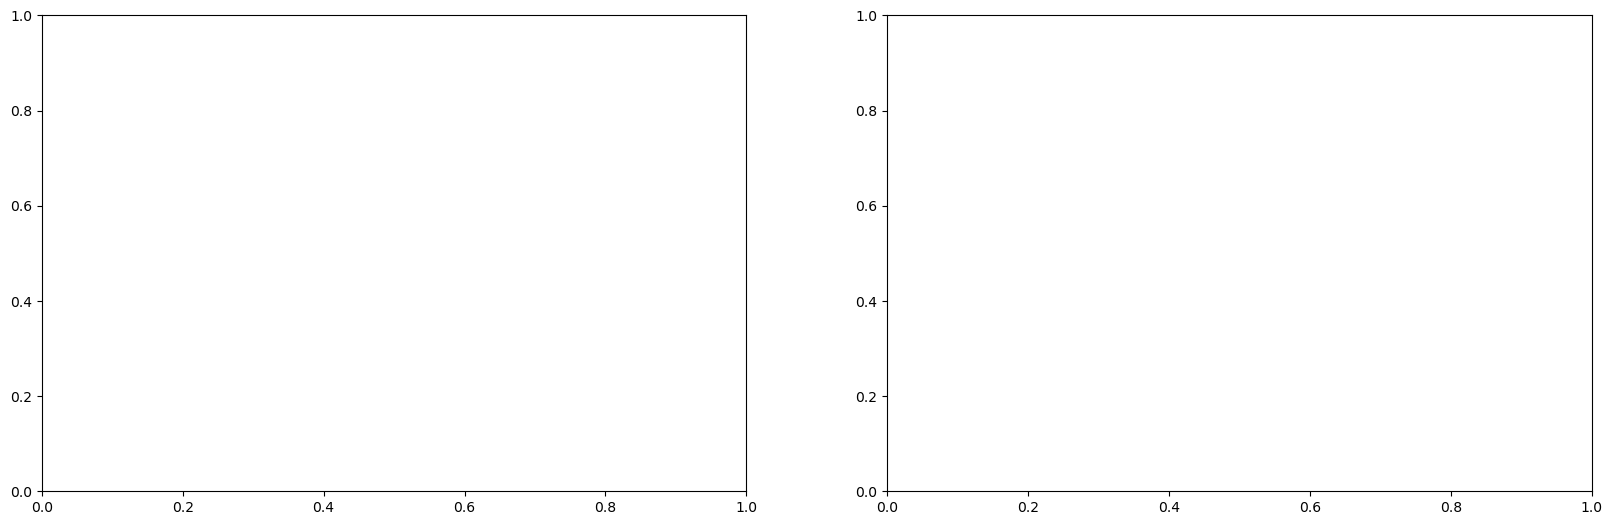

In [21]:
result_df = pd.read_csv('results/test1.csv')
winners_curse_df = pd.DataFrame({
    'plugin': result_df['plugin_est'] - result_df['plugin_act_val'], 
    'corr': result_df['correction_est'] - result_df['plugin_act_val'], 
    'adj_corr': result_df['adj_correction_est'] - result_df['plugin_act_val'], 
})

fig, axes = plt.subplots(1, 2, figsize=(20, 6.18))

axes[0].hist(winners_curse_df['plugin'], bins=20, alpha=0.6, color='C0', label='Plugin', density=True)
axes[0].axvline(winners_curse_df['plugin'].mean(), color='C0', linestyle='--', label='Plugin Mean')

axes[0].hist(winners_curse_df['corr'], bins=20, alpha=0.6, color='C1', label='Correction', density=True)
axes[0].axvline(winners_curse_df['corr'].mean(), color='C1', linestyle='--', label='Correction Mean')

axes[0].hist(winners_curse_df['adj_corr'], bins=20, alpha=0.6, color='C2', label='Adjusted Correction', density=True)
axes[0].axvline(winners_curse_df['adj_corr'].mean(), color='C2', linestyle='--', label='Adjusted Correction Mean')

axes[0].set_xlabel('Winner\'s Curse')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Winner\'s Curse of Different Estimators')


axes[0].grid()
axes[0].legend()

plt.show()

In [17]:
grid_results = grid_experiment(
    sample_sizes=[100, 500, 1000, 1500, 2000, 2500, 5000], 
    num_bootstraps=[1000, 5000, 10000, 15000, 20000],
    dgp_params=dgp_params,
    targeting_params=targeting_params,
    estimators_dict=estimators_dict,
    num_repeats=10, verbose=True
)

Sample size: 100, Num bootstrap: 1000, Time taken: 4.15 seconds
Sample size: 100, Num bootstrap: 5000, Time taken: 80.98 seconds
Sample size: 100, Num bootstrap: 10000, Time taken: 121.95 seconds
Sample size: 100, Num bootstrap: 15000, Time taken: 294.92 seconds
Sample size: 100, Num bootstrap: 20000, Time taken: 462.88 seconds
Sample size: 500, Num bootstrap: 1000, Time taken: 4.61 seconds
Sample size: 500, Num bootstrap: 5000, Time taken: 84.14 seconds
Sample size: 500, Num bootstrap: 10000, Time taken: 134.80 seconds
Sample size: 500, Num bootstrap: 15000, Time taken: 299.24 seconds
Sample size: 500, Num bootstrap: 20000, Time taken: 464.55 seconds
Sample size: 1000, Num bootstrap: 1000, Time taken: 4.91 seconds
Sample size: 1000, Num bootstrap: 5000, Time taken: 86.39 seconds
Sample size: 1000, Num bootstrap: 10000, Time taken: 130.78 seconds
Sample size: 1000, Num bootstrap: 15000, Time taken: 305.09 seconds
Sample size: 1000, Num bootstrap: 20000, Time taken: 457.64 seconds
Sampl

In [18]:
# aggregate results into a dataframe
result_df = pd.DataFrame.from_records([
    {
        'sample_size': result_dict['sample_size'],
        'num_bootstrap': result_dict['num_bootstrap'],
        'plugin': result_dict['plugin']['targ_est'],
        'act_plugin': result_dict['plugin']['act_targ_val'], 
        'corr': result_dict['correction']['targ_est'],
        'adj_corr': result_dict['adj_correction']['targ_est'],
    }
    for result_dict in grid_results
])

result_df = result_df.groupby(['sample_size', 'num_bootstrap']).mean().reset_index()

# calculate winner's curse
result_df['plugin_wc'] = result_df['plugin'] - result_df['act_plugin']
result_df['corr_wc'] = result_df['corr'] - result_df['act_plugin']
result_df['adj_corr_wc'] = result_df['adj_corr'] - result_df['act_plugin']

result_df.to_csv('results/grid1.csv', index=False)

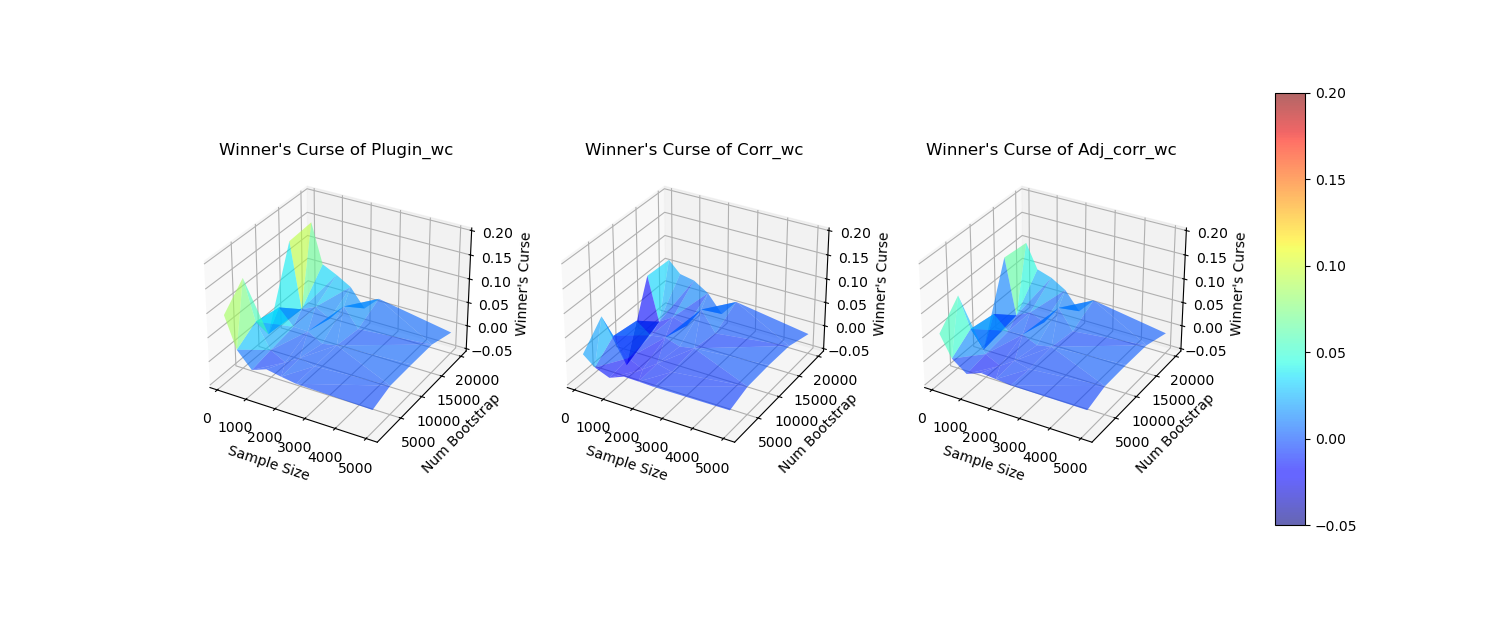

In [16]:
vmin = -0.05
vmax = 0.2

result_df = pd.read_csv('results/grid1.csv')

# make a 3D plot, sample size vs num bootstrap vs winner's curse
fig, axes = plt.subplots(1, 3, figsize=(15, 6.18), subplot_kw={'projection': '3d'})

for estimator, ax in zip(['plugin_wc', 'corr_wc', 'adj_corr_wc'], axes):
    surf = ax.plot_trisurf(
        result_df['sample_size'], result_df['num_bootstrap'], result_df[estimator], 
        cmap=cm.jet, alpha=0.6, label=estimator, vmin=vmin, vmax=vmax
    )
    ax.set_title(f'Winner\'s Curse of {estimator.capitalize()}')
    ax.set_xlabel('Sample Size')
    ax.set_ylabel('Num Bootstrap')
    ax.set_zlabel('Winner\'s Curse')
    ax.set_zlim(vmin, vmax)

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
fig.colorbar(surf, cax=cbar_ax)

plt.show()

### Test 1.1

In [13]:
# parameters
dgp_params = {
    'te_list': [1.0, 1.1],  # treatment effects for each group
    'group_func': lambda x: 0 if x < 0 else 1,  # group function
    'noise_std': 5.0,  # noise standard deviation
    'train_size': 100  # size of training set
}
targeting_params = {
    'size': 10,  # number of arriving customers
    'budget': 1,  # number of customers to target
}
estimators_dict = {
    'plugin': {
        'estimator': BinaryPlugIn, 
        'train_params': {}, 
        'targeting_params': {}, 
    },  # plugin estimator
    # 'bootstrap': {
    #     'estimator': BinaryBootstrap, 
    #     'train_params': {'boot_size': 50, 'n_bootstrap': 10000},
    #     'targeting_params': {},
    # },  # bootstrap estimator
    'correction': {
        'estimator': BinaryCorrection, 
        'train_params': {'n_bootstrap': 10000},
        'targeting_params': {},
    },  # bootstrap correction estimator
    'adj_correction': {
        'estimator': BinaryAdjustedCorrection, 
        'train_params': {'n_bootstrap': 10000},
        'targeting_params': {},
    }  # adjusted bootstrap correction estimator
}

In [14]:
# run experiments
repeated_exp_results = [
    single_experiment(
        dgp_params, targeting_params, estimators_dict, seed=0, save_estimator=True
    ) for _ in tqdm(range(100))
]

100%|██████████| 100/100 [21:46<00:00, 13.06s/it]


In [15]:
result_df = pd.DataFrame.from_records([
    {
        'clairvoyant': result_dict['clairvoyant'],
        'plugin_est': result_dict['plugin']['targ_est'],
        'plugin_act_val': result_dict['plugin']['act_targ_val'],  # actual value of the plugin targeting decision
        'correction_est': result_dict['correction']['targ_est'],
        'adj_correction_est': result_dict['adj_correction']['targ_est'],
    }
    for result_dict in repeated_exp_results
])
result_df.to_csv('results/test11.csv', index=False)

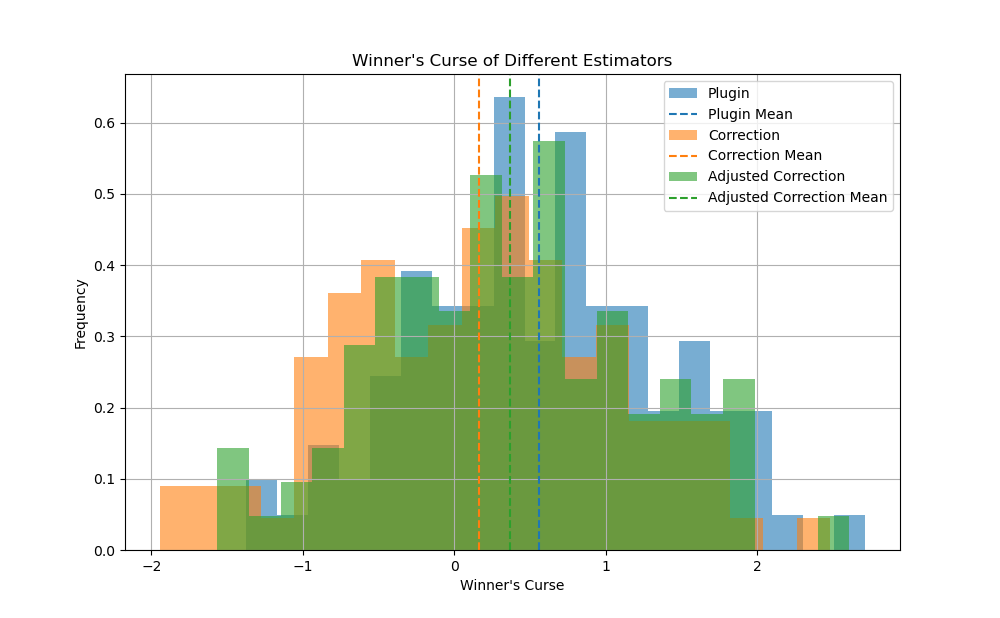

In [16]:
result_df = pd.read_csv('results/test11.csv')
winners_curse_df = pd.DataFrame({
    'plugin': result_df['plugin_est'] - result_df['plugin_act_val'], 
    'corr': result_df['correction_est'] - result_df['plugin_act_val'], 
    'adj_corr': result_df['adj_correction_est'] - result_df['plugin_act_val'], 
})

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))
# sns.histplot(winners_curse_df, bins=20, kde=True, ax=ax, stat='density')
ax.hist(winners_curse_df['plugin'], bins=20, alpha=0.6, color='C0', label='Plugin', density=True)
ax.axvline(winners_curse_df['plugin'].mean(), color='C0', linestyle='--', label='Plugin Mean')

ax.hist(winners_curse_df['corr'], bins=20, alpha=0.6, color='C1', label='Correction', density=True)
ax.axvline(winners_curse_df['corr'].mean(), color='C1', linestyle='--', label='Correction Mean')

ax.hist(winners_curse_df['adj_corr'], bins=20, alpha=0.6, color='C2', label='Adjusted Correction', density=True)
ax.axvline(winners_curse_df['adj_corr'].mean(), color='C2', linestyle='--', label='Adjusted Correction Mean')

ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Frequency')
ax.set_title('Winner\'s Curse of Different Estimators')

ax.grid()
ax.legend()

plt.show()

In [ ]:
grid_results = grid_experiment(
    sample_sizes=[100, 500, 1000, 1500, 2000, 2500, 5000], 
    num_bootstraps=[1000, 5000, 10000, 15000, 20000],
    dgp_params=dgp_params,
    targeting_params=targeting_params,
    estimators_dict=estimators_dict,
    num_repeats=10, verbose=True
)

In [ ]:
# aggregate results into a dataframe
result_df = pd.DataFrame.from_records([
    {
        'sample_size': result_dict['sample_size'],
        'num_bootstrap': result_dict['num_bootstrap'],
        'plugin': result_dict['plugin']['targ_est'],
        'act_plugin': result_dict['plugin']['act_targ_val'], 
        'corr': result_dict['correction']['targ_est'],
        'adj_corr': result_dict['adj_correction']['targ_est'],
    }
    for result_dict in grid_results
])

result_df = result_df.groupby(['sample_size', 'num_bootstrap']).mean().reset_index()

# calculate winner's curse
result_df['plugin_wc'] = result_df['plugin'] - result_df['act_plugin']
result_df['corr_wc'] = result_df['corr'] - result_df['act_plugin']
result_df['adj_corr_wc'] = result_df['adj_corr'] - result_df['act_plugin']

result_df.to_csv('results/grid1.csv', index=False)

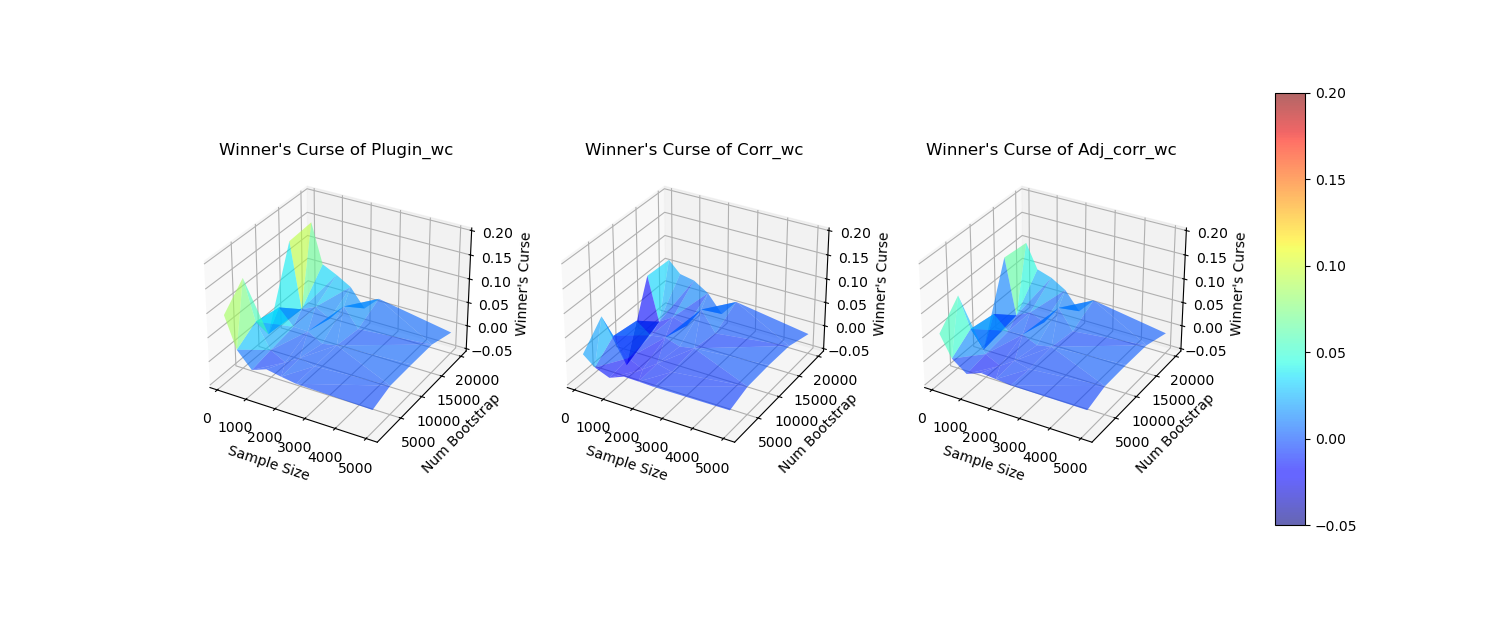

In [ ]:
vmin = -0.05
vmax = 0.2

result_df = pd.read_csv('results/grid1.csv')

# make a 3D plot, sample size vs num bootstrap vs winner's curse
fig, axes = plt.subplots(1, 3, figsize=(15, 6.18), subplot_kw={'projection': '3d'})

for estimator, ax in zip(['plugin_wc', 'corr_wc', 'adj_corr_wc'], axes):
    surf = ax.plot_trisurf(
        result_df['sample_size'], result_df['num_bootstrap'], result_df[estimator], 
        cmap=cm.jet, alpha=0.6, label=estimator, vmin=vmin, vmax=vmax
    )
    ax.set_title(f'Winner\'s Curse of {estimator.capitalize()}')
    ax.set_xlabel('Sample Size')
    ax.set_ylabel('Num Bootstrap')
    ax.set_zlabel('Winner\'s Curse')
    ax.set_zlim(vmin, vmax)

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
fig.colorbar(surf, cax=cbar_ax)

plt.show()

### Test 1.2

In [20]:
# parameters
dgp_params = {
    'te_list': [1.0, 1.1],  # treatment effects for each group
    'group_func': lambda x: 0 if x < 0 else 1,  # group function
    'train_size': 1000  # size of training set
}
targeting_params = {
    'size': 10,  # number of arriving customers
    'budget': 1,  # number of customers to target
}
estimators_dict = {
    'plugin': {
        'estimator': BinaryPlugIn, 
        'train_params': {}, 
        'targeting_params': {}, 
    },  # plugin estimator
    # 'bootstrap': {
    #     'estimator': BinaryBootstrap, 
    #     'train_params': {'boot_size': 500, 'n_bootstrap': 10000},
    #     'targeting_params': {},
    # },  # bootstrap estimator
    'correction': {
        'estimator': BinaryCorrection, 
        'train_params': {'n_bootstrap': 10000},
        'targeting_params': {},
    },  # bootstrap correction estimator
    'adj_correction': {
        'estimator': BinaryAdjustedCorrection, 
        'train_params': {'n_bootstrap': 10000},
        'targeting_params': {},
    }  # adjusted bootstrap correction estimator
}

In [22]:
# run experiments
repeated_exp_results = [
    single_experiment(
        dgp_params, targeting_params, estimators_dict, seed=0
    ) for _ in tqdm(range(100))
]

100%|██████████| 100/100 [25:04<00:00, 15.05s/it]


In [23]:
result_df = pd.DataFrame.from_records([
    {
        'clairvoyant': result_dict['clairvoyant'],
        'plugin_est': result_dict['plugin']['targ_est'],
        'plugin_act_val': result_dict['plugin']['act_targ_val'],  # actual value of the plugin targeting decision
        'correction_est': result_dict['correction']['targ_est'],
        'adj_correction_est': result_dict['adj_correction']['targ_est'],
    }
    for result_dict in repeated_exp_results
])
result_df.to_csv('results/test2.csv', index=False)

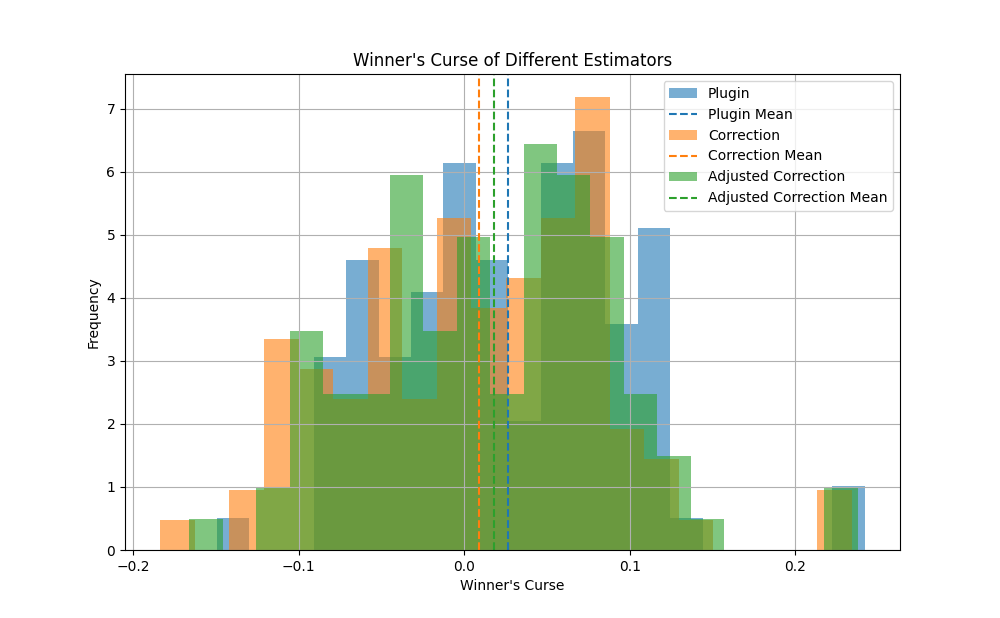

In [24]:
result_df = pd.read_csv('results/test2.csv')
winners_curse_df = pd.DataFrame({
    'plugin': result_df['plugin_est'] - result_df['plugin_act_val'], 
    'corr': result_df['correction_est'] - result_df['plugin_act_val'], 
    'adj_corr': result_df['adj_correction_est'] - result_df['plugin_act_val'], 
})

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))
# sns.histplot(winners_curse_df, bins=20, kde=True, ax=ax, stat='density')
ax.hist(winners_curse_df['plugin'], bins=20, alpha=0.6, color='C0', label='Plugin', density=True)
ax.axvline(winners_curse_df['plugin'].mean(), color='C0', linestyle='--', label='Plugin Mean')

ax.hist(winners_curse_df['corr'], bins=20, alpha=0.6, color='C1', label='Correction', density=True)
ax.axvline(winners_curse_df['corr'].mean(), color='C1', linestyle='--', label='Correction Mean')

ax.hist(winners_curse_df['adj_corr'], bins=20, alpha=0.6, color='C2', label='Adjusted Correction', density=True)
ax.axvline(winners_curse_df['adj_corr'].mean(), color='C2', linestyle='--', label='Adjusted Correction Mean')

ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Frequency')
ax.set_title('Winner\'s Curse of Different Estimators')

ax.grid()
ax.legend()

plt.show()

In [25]:
grid_results = grid_experiment(
    sample_sizes=[100, 500, 1000, 1500, 2000, 2500, 5000], 
    num_bootstraps=[1000, 5000, 10000, 15000, 20000],
    dgp_params=dgp_params,
    targeting_params=targeting_params,
    estimators_dict=estimators_dict,
    num_repeats=20, verbose=True
)

Sample size: 100, Num bootstrap: 1000, Time taken: 8.02 seconds
Sample size: 100, Num bootstrap: 5000, Time taken: 72.13 seconds
Sample size: 100, Num bootstrap: 10000, Time taken: 243.64 seconds
Sample size: 100, Num bootstrap: 15000, Time taken: 516.43 seconds
Sample size: 100, Num bootstrap: 20000, Time taken: 950.06 seconds
Sample size: 500, Num bootstrap: 1000, Time taken: 9.50 seconds
Sample size: 500, Num bootstrap: 5000, Time taken: 80.21 seconds
Sample size: 500, Num bootstrap: 10000, Time taken: 252.33 seconds
Sample size: 500, Num bootstrap: 15000, Time taken: 519.19 seconds
Sample size: 500, Num bootstrap: 20000, Time taken: 975.67 seconds
Sample size: 1000, Num bootstrap: 1000, Time taken: 10.48 seconds
Sample size: 1000, Num bootstrap: 5000, Time taken: 84.63 seconds
Sample size: 1000, Num bootstrap: 10000, Time taken: 267.63 seconds
Sample size: 1000, Num bootstrap: 15000, Time taken: 534.10 seconds
Sample size: 1000, Num bootstrap: 20000, Time taken: 970.91 seconds
Samp

In [28]:
# aggregate results into a dataframe
result_df = pd.DataFrame.from_records([
    {
        'sample_size': result_dict['sample_size'],
        'num_bootstrap': result_dict['num_bootstrap'],
        'plugin': result_dict['plugin']['targ_est'],
        'act_plugin': result_dict['plugin']['act_targ_val'], 
        'corr': result_dict['correction']['targ_est'],
        'adj_corr': result_dict['adj_correction']['targ_est'],
    }
    for result_dict in grid_results
])

result_df = result_df.groupby(['sample_size', 'num_bootstrap']).mean().reset_index()

# calculate winner's curse
result_df['plugin_wc'] = result_df['plugin'] - result_df['act_plugin']
result_df['corr_wc'] = result_df['corr'] - result_df['act_plugin']
result_df['adj_corr_wc'] = result_df['adj_corr'] - result_df['act_plugin']

result_df.to_csv('results/grid2.csv', index=False)

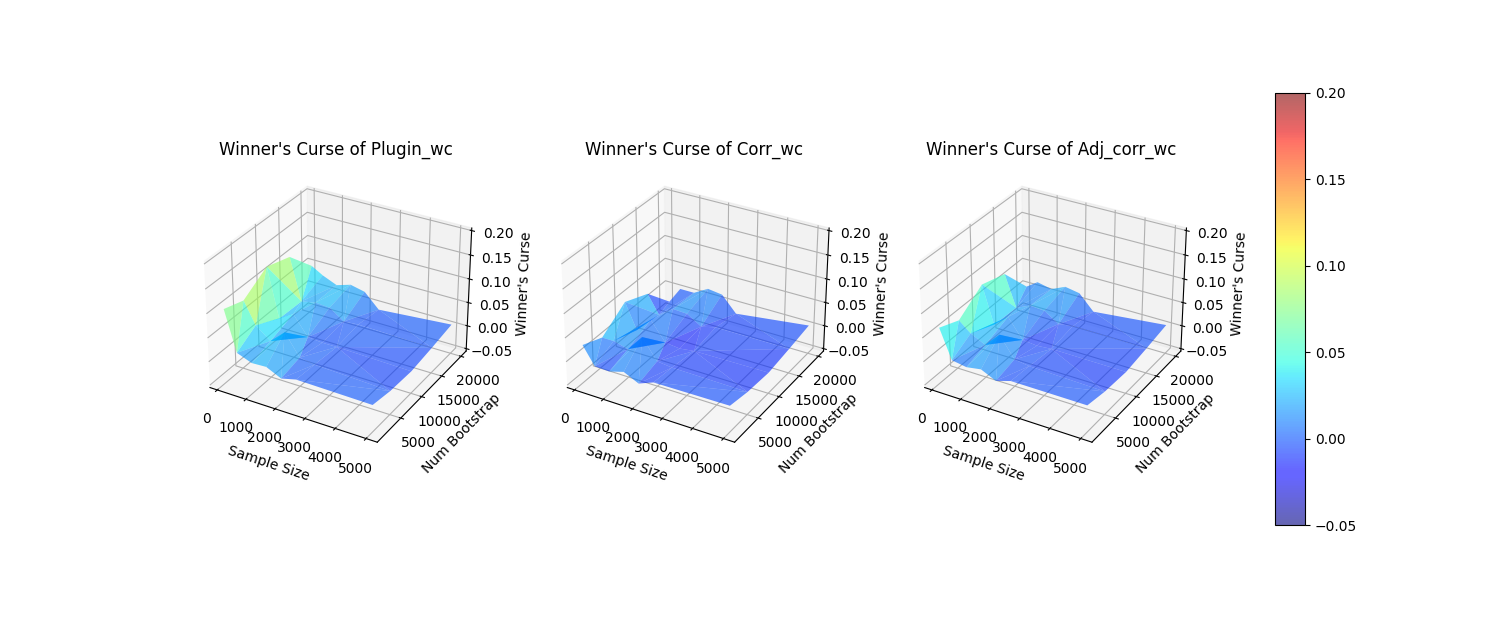

In [29]:
vmin = -0.05
vmax = 0.2

result_df = pd.read_csv('results/grid2.csv')

# make a 3D plot, sample size vs num bootstrap vs winner's curse
fig, axes = plt.subplots(1, 3, figsize=(15, 6.18), subplot_kw={'projection': '3d'})

for estimator, ax in zip(['plugin_wc', 'corr_wc', 'adj_corr_wc'], axes):
    surf = ax.plot_trisurf(
        result_df['sample_size'], result_df['num_bootstrap'], result_df[estimator], 
        cmap=cm.jet, alpha=0.6, label=estimator, vmin=vmin, vmax=vmax
    )
    ax.set_title(f'Winner\'s Curse of {estimator.capitalize()}')
    ax.set_xlabel('Sample Size')
    ax.set_ylabel('Num Bootstrap')
    ax.set_zlabel('Winner\'s Curse')
    ax.set_zlim(vmin, vmax)

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
fig.colorbar(surf, cax=cbar_ax)

plt.show()

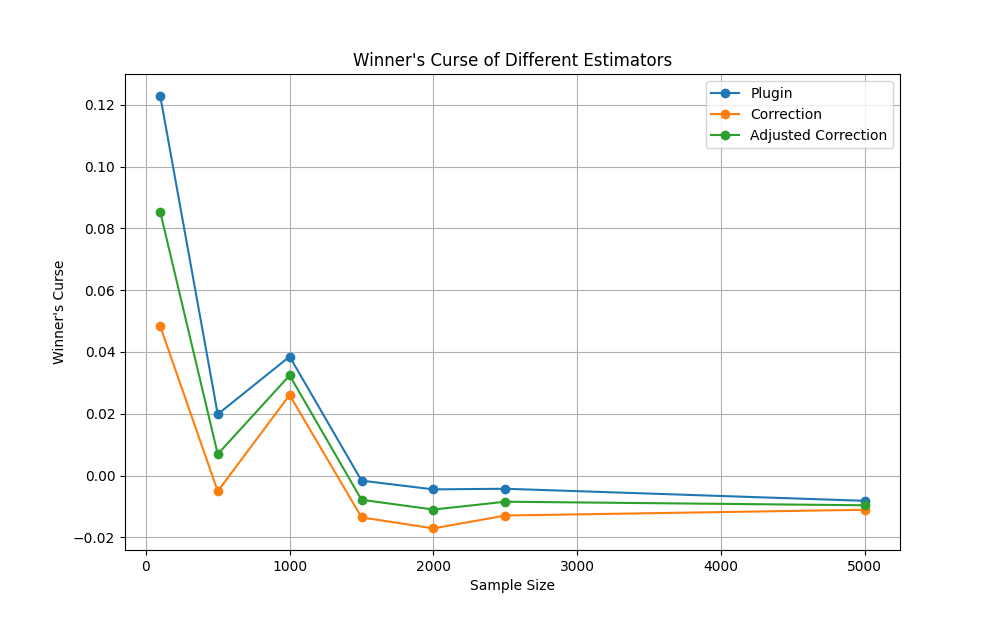

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))
test = result_df[result_df['num_bootstrap'] == 10000]

ax.plot(test['sample_size'], test['plugin_wc'], 'o-', label='Plugin', color='C0')
ax.plot(test['sample_size'], test['corr_wc'], 'o-', label='Correction', color='C1')
ax.plot(test['sample_size'], test['adj_corr_wc'], 'o-', label='Adjusted Correction', color='C2')

ax.set_xlabel('Sample Size')
ax.set_ylabel('Winner\'s Curse')
ax.set_title('Winner\'s Curse of Different Estimators')
ax.grid()
ax.legend()

plt.show()

## Test 3

In [31]:
# parameters
def group_func(x):
    if x <= -1.5:
        return 0
    elif x <= 0:
        return 1
    elif x <= 1.5:
        return 2
    else:
        return 3
    
dgp_params = {
    'te_list': [0.9, 1.0, 1.1, 1.2],  # treatment effects for each group
    'group_func': group_func,  # group function
    'train_size': 100  # size of training set
}
targeting_params = {
    'size': 20,  # number of arriving customers
    'budget': 5,  # number of customers to target
}
estimators_dict = {
    'plugin': {
        'estimator': BinaryPlugIn, 
        'train_params': {}, 
        'targeting_params': {}, 
    },  # plugin estimator
    # 'bootstrap': {
    #     'estimator': BinaryBootstrap, 
    #     'train_params': {'boot_size': 50, 'n_bootstrap': 10000},
    #     'targeting_params': {},
    # },  # bootstrap estimator
    'correction': {
        'estimator': BinaryCorrection, 
        'train_params': {'n_bootstrap': 10000},
        'targeting_params': {},
    },  # bootstrap correction estimator
    'adj_correction': {
        'estimator': BinaryAdjustedCorrection, 
        'train_params': {'n_bootstrap': 10000},
        'targeting_params': {},
    }  # adjusted bootstrap correction estimator
}

In [33]:
# run experiments
repeated_exp_results = [
    single_experiment(
        dgp_params, targeting_params, estimators_dict, seed=0
    ) for _ in tqdm(range(100))
]

  9%|▉         | 9/100 [05:16<52:45, 34.78s/it]  

In [ ]:
result_df = pd.DataFrame.from_records([
    {
        'clairvoyant': result_dict['clairvoyant'],
        'plugin_est': result_dict['plugin']['targ_est'],
        'plugin_act_val': result_dict['plugin']['act_targ_val'],  # actual value of the plugin targeting decision
        'correction_est': result_dict['correction']['targ_est'],
        'adj_correction_est': result_dict['adj_correction']['targ_est'],
    }
    for result_dict in repeated_exp_results
])
result_df.to_csv('results/test3.csv', index=False)

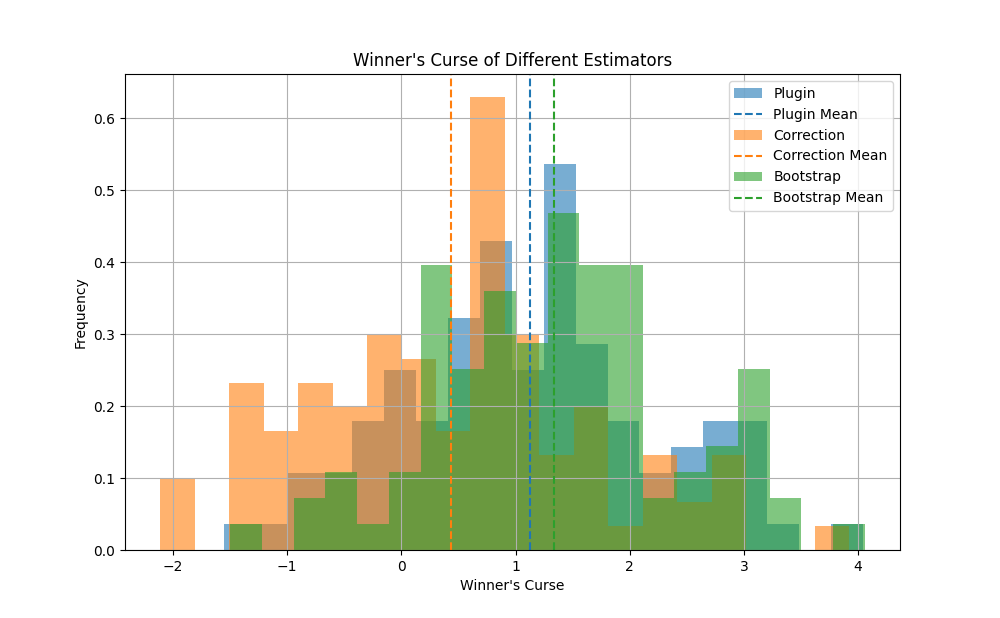

In [ ]:
result_df = pd.read_csv('results/test3.csv')
winners_curse_df = pd.DataFrame({
    'plugin': result_df['plugin_est'] - result_df['plugin_act_val'], 
    'corr': result_df['correction_est'] - result_df['plugin_act_val'], 
    'adj_corr': result_df['adj_correction_est'] - result_df['plugin_act_val'],
})

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))
# sns.histplot(winners_curse_df, bins=20, kde=True, ax=ax, stat='density')
ax.hist(winners_curse_df['plugin'], bins=20, alpha=0.6, color='C0', label='Plugin', density=True)
ax.axvline(winners_curse_df['plugin'].mean(), color='C0', linestyle='--', label='Plugin Mean')

ax.hist(winners_curse_df['corr'], bins=20, alpha=0.6, color='C1', label='Correction', density=True)
ax.axvline(winners_curse_df['corr'].mean(), color='C1', linestyle='--', label='Correction Mean')

ax.hist(winners_curse_df['adj_corr'], bins=20, alpha=0.6, color='C2', label='Adj Correction', density=True)
ax.axvline(winners_curse_df['adj_corr'].mean(), color='C2', linestyle='--', label='Adj Correction Mean')

ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Frequency')
ax.set_title('Winner\'s Curse of Different Estimators')

ax.grid()
ax.legend()

plt.show()

In [ ]:
grid_results = grid_experiment(
    sample_sizes=[100, 500, 1000, 1500, 2000, 2500, 5000], 
    num_bootstraps=[1000, 5000, 10000, 15000, 20000],
    dgp_params=dgp_params,
    targeting_params=targeting_params,
    estimators_dict=estimators_dict,
    num_repeats=10, verbose=True
)

Sample size: 100, Num bootstrap: 1000, Time taken: 168.47 seconds
Sample size: 100, Num bootstrap: 5000, Time taken: 182.17 seconds
Sample size: 100, Num bootstrap: 10000, Time taken: 190.26 seconds
Sample size: 100, Num bootstrap: 15000, Time taken: 210.53 seconds
Sample size: 100, Num bootstrap: 20000, Time taken: 232.87 seconds
Sample size: 500, Num bootstrap: 1000, Time taken: 177.53 seconds
Sample size: 500, Num bootstrap: 5000, Time taken: 184.98 seconds
Sample size: 500, Num bootstrap: 10000, Time taken: 206.43 seconds
Sample size: 500, Num bootstrap: 15000, Time taken: 214.56 seconds
Sample size: 500, Num bootstrap: 20000, Time taken: 234.20 seconds
Sample size: 1000, Num bootstrap: 1000, Time taken: 172.25 seconds
Sample size: 1000, Num bootstrap: 5000, Time taken: 191.10 seconds
Sample size: 1000, Num bootstrap: 10000, Time taken: 209.55 seconds
Sample size: 1000, Num bootstrap: 15000, Time taken: 226.70 seconds
Sample size: 1000, Num bootstrap: 20000, Time taken: 237.02 seco

In [ ]:
# aggregate results into a dataframe
result_df = pd.DataFrame.from_records([
    {
        'sample_size': result_dict['sample_size'],
        'num_bootstrap': result_dict['num_bootstrap'],
        'plugin': result_dict['plugin']['targ_est'],
        'act_plugin': result_dict['plugin']['act_targ_val'], 
        'corr': result_dict['correction']['targ_est'],
        'adj_corr': result_dict['adj_correction']['targ_est'],
    }
    for result_dict in grid_results
])

result_df = result_df.groupby(['sample_size', 'num_bootstrap']).mean().reset_index()

# calculate winner's curse
result_df['plugin_wc'] = result_df['plugin'] - result_df['act_plugin']
result_df['corr_wc'] = result_df['corr'] - result_df['act_plugin']
result_df['adj_corr_wc'] = result_df['adj_corr'] - result_df['act_plugin']

result_df.to_csv('results/grid3.csv', index=False)

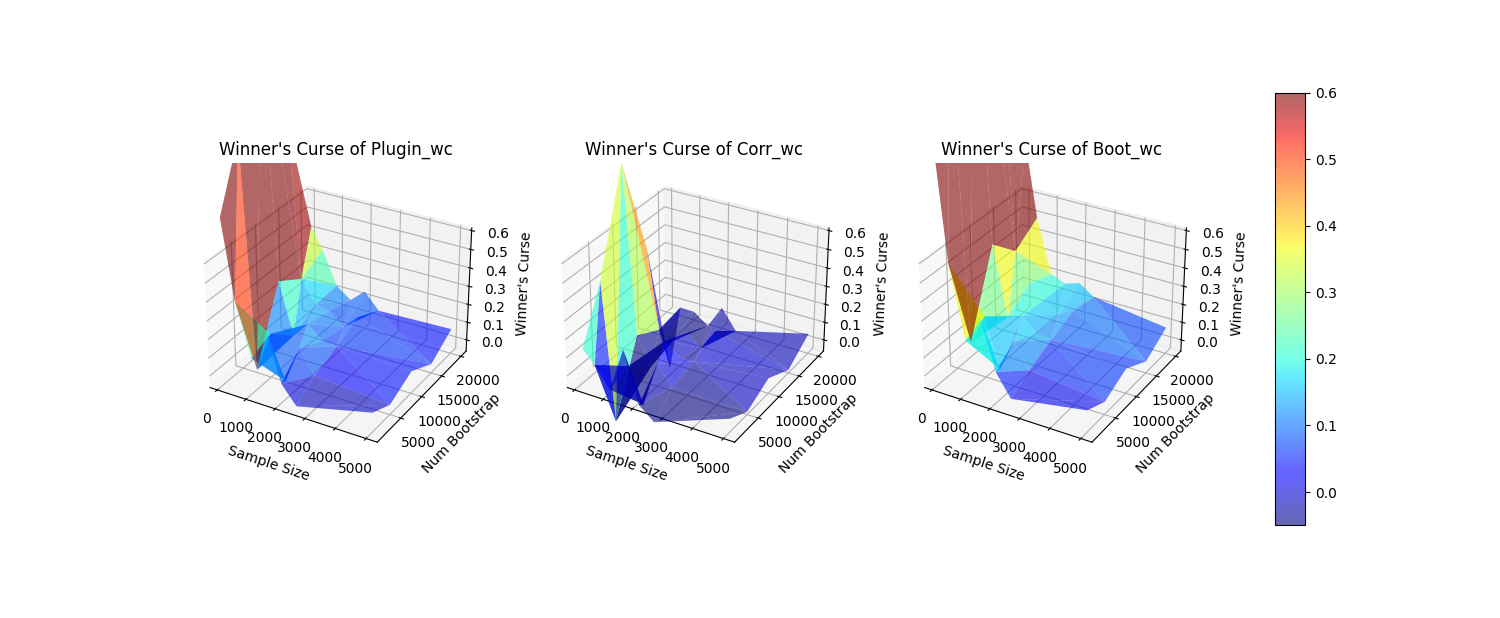

In [ ]:
vmin = -0.05
vmax = 0.6

result_df = pd.read_csv('results/grid3.csv')

# make a 3D plot, sample size vs num bootstrap vs winner's curse
fig, axes = plt.subplots(1, 3, figsize=(15, 6.18), subplot_kw={'projection': '3d'})

for estimator, ax in zip(['plugin_wc', 'corr_wc', 'adj_corr_wc'], axes):
    surf = ax.plot_trisurf(
        result_df['sample_size'], result_df['num_bootstrap'], result_df[estimator], 
        cmap=cm.jet, alpha=0.6, label=estimator, vmin=vmin, vmax=vmax
    )
    ax.set_title(f'Winner\'s Curse of {estimator.capitalize()}')
    ax.set_xlabel('Sample Size')
    ax.set_ylabel('Num Bootstrap')
    ax.set_zlabel('Winner\'s Curse')
    ax.set_zlim(vmin, vmax)

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
fig.colorbar(surf, cax=cbar_ax)

plt.show()

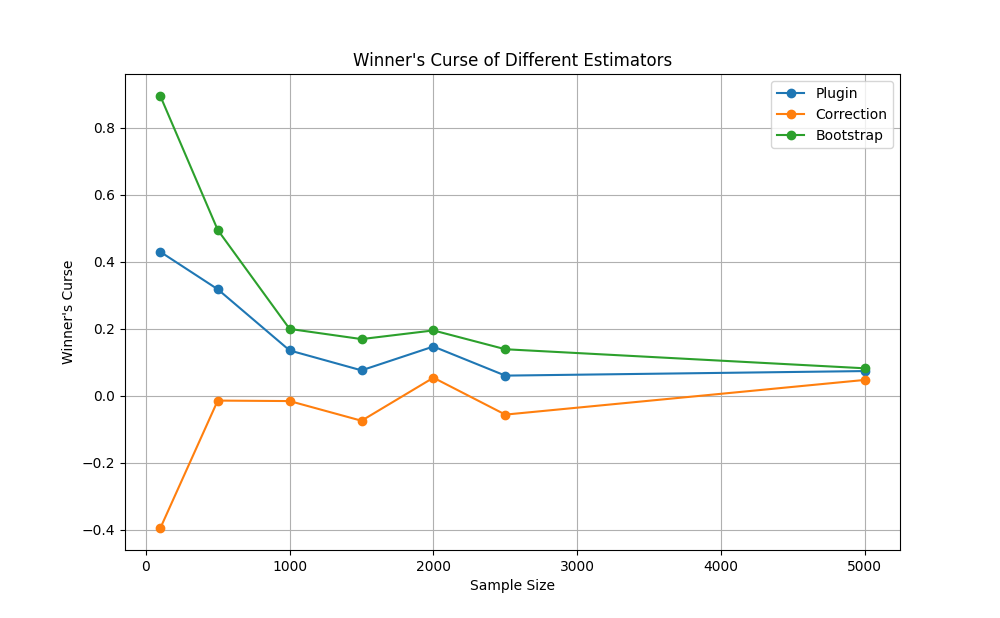

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))
test = result_df[result_df['num_bootstrap'] == 20000]

ax.plot(test['sample_size'], test['plugin_wc'], 'o-', label='Plugin', color='C0')
ax.plot(test['sample_size'], test['corr_wc'], 'o-', label='Correction', color='C1')
ax.plot(test['sample_size'], test['adj_corr_wc'], 'o-', label='Adjusted Correction', color='C2')

ax.set_xlabel('Sample Size')
ax.set_ylabel('Winner\'s Curse')
ax.set_title('Winner\'s Curse of Different Estimators')
ax.grid()
ax.legend()

plt.show()

## Test 4

In [26]:
# parameters
def group_func(x):
    if x <= -1.5:
        return 0
    elif x <= 0:
        return 1
    elif x <= 1.5:
        return 2
    else:
        return 3
    
dgp_params = {
    'te_list': [0.9, 1.0, 1.1, 1.2],  # treatment effects for each group
    'group_func': group_func,  # group function
    'train_size': 1000  # size of training set
}
targeting_params = {
    'size': 20,  # number of arriving customers
    'budget': 5,  # number of customers to target
}
estimators_dict = {
    'plugin': {
        'estimator': BinaryPlugIn, 
        'train_params': {}, 
        'targeting_params': {}, 
    },  # plugin estimator
    # 'bootstrap': {
    #     'estimator': BinaryBootstrap, 
    #     'train_params': {'boot_size': 200, 'n_bootstrap': 10000},
    #     'targeting_params': {},
    # },  # bootstrap estimator
    'correction': {
        'estimator': BinaryCorrection, 
        'train_params': {'n_bootstrap': 10000},
        'targeting_params': {},
    },  # bootstrap correction estimator
    'adj_correction': {
        'estimator': BinaryAdjustedCorrection, 
        'train_params': {'n_bootstrap': 10000},
        'targeting_params': {},
    }  # adjusted bootstrap correction estimator
}

In [27]:
# run experiments
repeated_exp_results = [
    single_experiment(
        dgp_params, targeting_params, estimators_dict, seed=0
    ) for _ in tqdm(range(100))
]

In [ ]:
result_df = pd.DataFrame.from_records([
    {
        'clairvoyant': result_dict['clairvoyant'],
        'plugin_est': result_dict['plugin']['targ_est'],
        'plugin_act_val': result_dict['plugin']['act_targ_val'],  # actual value of the plugin targeting decision
        'correction_est': result_dict['correction']['targ_est'],
        'adj_correction_est': result_dict['adj_correction']['targ_est'],
    }
    for result_dict in repeated_exp_results
])
result_df.to_csv('results/test4.csv', index=False)

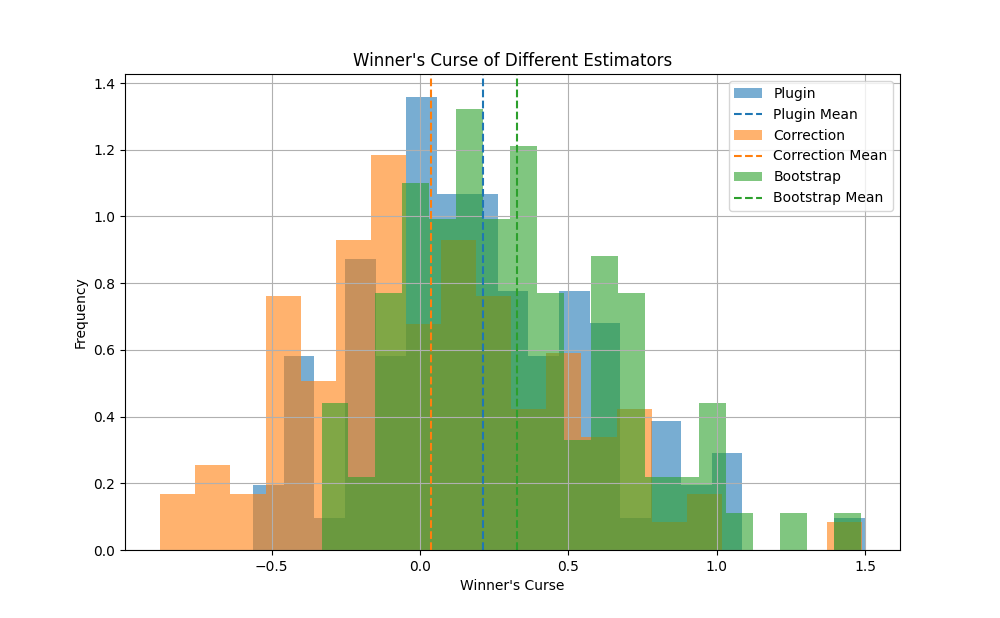

In [ ]:
result_df = pd.read_csv('results/test4.csv')
winners_curse_df = pd.DataFrame({
    'plugin': result_df['plugin_est'] - result_df['plugin_act_val'], 
    'corr': result_df['correction_est'] - result_df['plugin_act_val'], 
    'adj_corr': result_df['adj_correction_est'] - result_df['plugin_act_val']
})

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))
# sns.histplot(winners_curse_df, bins=20, kde=True, ax=ax, stat='density')
ax.hist(winners_curse_df['plugin'], bins=20, alpha=0.6, color='C0', label='Plugin', density=True)
ax.axvline(winners_curse_df['plugin'].mean(), color='C0', linestyle='--', label='Plugin Mean')

ax.hist(winners_curse_df['corr'], bins=20, alpha=0.6, color='C1', label='Correction', density=True)
ax.axvline(winners_curse_df['corr'].mean(), color='C1', linestyle='--', label='Correction Mean')

ax.hist(winners_curse_df['adj_corr'], bins=20, alpha=0.6, color='C2', label='Adj Correction', density=True)
ax.axvline(winners_curse_df['adj_corr'].mean(), color='C2', linestyle='--', label='Adj Correction Mean')

ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Frequency')
ax.set_title('Winner\'s Curse of Different Estimators')

ax.grid()
ax.legend()

plt.show()

In [ ]:
grid_results = grid_experiment(
    sample_sizes=[100, 500, 1000, 1500, 2000, 2500, 5000], 
    num_bootstraps=[1000, 5000, 10000, 15000, 20000],
    dgp_params=dgp_params,
    targeting_params=targeting_params,
    estimators_dict=estimators_dict,
    num_repeats=10, verbose=True
)

Sample size: 100, Num bootstrap: 1000, Time taken: 171.62 seconds
Sample size: 100, Num bootstrap: 5000, Time taken: 190.58 seconds
Sample size: 100, Num bootstrap: 10000, Time taken: 192.00 seconds
Sample size: 100, Num bootstrap: 15000, Time taken: 215.49 seconds
Sample size: 100, Num bootstrap: 20000, Time taken: 236.50 seconds
Sample size: 500, Num bootstrap: 1000, Time taken: 174.62 seconds
Sample size: 500, Num bootstrap: 5000, Time taken: 185.29 seconds
Sample size: 500, Num bootstrap: 10000, Time taken: 200.47 seconds
Sample size: 500, Num bootstrap: 15000, Time taken: 221.38 seconds
Sample size: 500, Num bootstrap: 20000, Time taken: 242.51 seconds
Sample size: 1000, Num bootstrap: 1000, Time taken: 174.03 seconds
Sample size: 1000, Num bootstrap: 5000, Time taken: 184.44 seconds
Sample size: 1000, Num bootstrap: 10000, Time taken: 211.72 seconds
Sample size: 1000, Num bootstrap: 15000, Time taken: 230.23 seconds
Sample size: 1000, Num bootstrap: 20000, Time taken: 237.87 seco

In [ ]:
# aggregate results into a dataframe
result_df = pd.DataFrame.from_records([
    {
        'sample_size': result_dict['sample_size'],
        'num_bootstrap': result_dict['num_bootstrap'],
        'plugin': result_dict['plugin']['targ_est'],
        'act_plugin': result_dict['plugin']['act_targ_val'], 
        'corr': result_dict['correction']['targ_est'],
        'adj_corr': result_dict['adj_correction']['targ_est'],
    }
    for result_dict in grid_results
])

result_df = result_df.groupby(['sample_size', 'num_bootstrap']).mean().reset_index()

# calculate winner's curse
result_df['plugin_wc'] = result_df['plugin'] - result_df['act_plugin']
result_df['corr_wc'] = result_df['corr'] - result_df['act_plugin']
result_df['adj_corr_wc'] = result_df['adj_corr'] - result_df['act_plugin']

result_df.to_csv('results/grid4.csv', index=False)

/var/folders/3l/3v_7k8t579j60k6cv9rj77080000gn/T/ipykernel_52948/2414091084.py:7: RuntimeWarning:

More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).



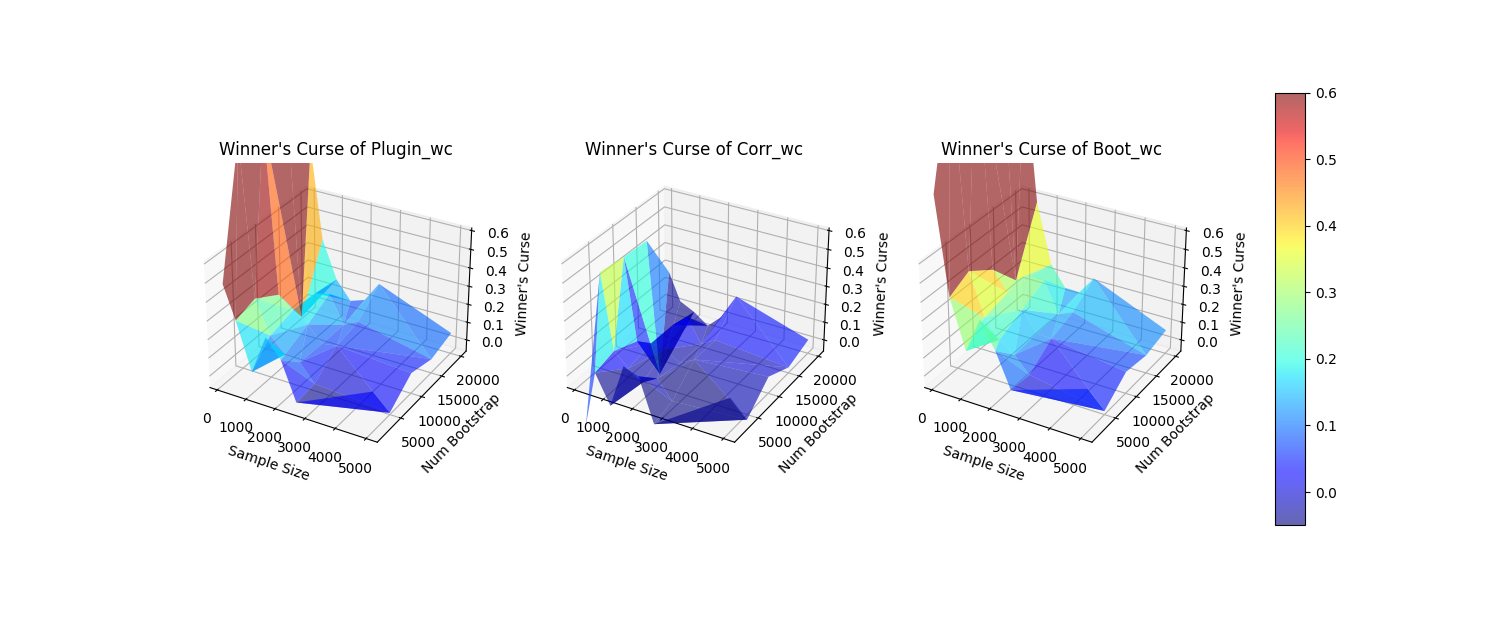

In [ ]:
vmin = -0.05
vmax = 0.6

result_df = pd.read_csv('results/grid4.csv')

# make a 3D plot, sample size vs num bootstrap vs winner's curse
fig, axes = plt.subplots(1, 3, figsize=(15, 6.18), subplot_kw={'projection': '3d'})

for estimator, ax in zip(['plugin_wc', 'corr_wc', 'adj_corr_wc'], axes):
    surf = ax.plot_trisurf(
        result_df['sample_size'], result_df['num_bootstrap'], result_df[estimator], 
        cmap=cm.jet, alpha=0.6, label=estimator, vmin=vmin, vmax=vmax
    )
    ax.set_title(f'Winner\'s Curse of {estimator.capitalize()}')
    ax.set_xlabel('Sample Size')
    ax.set_ylabel('Num Bootstrap')
    ax.set_zlabel('Winner\'s Curse')
    ax.set_zlim(vmin, vmax)

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
fig.colorbar(surf, cax=cbar_ax)

plt.show()

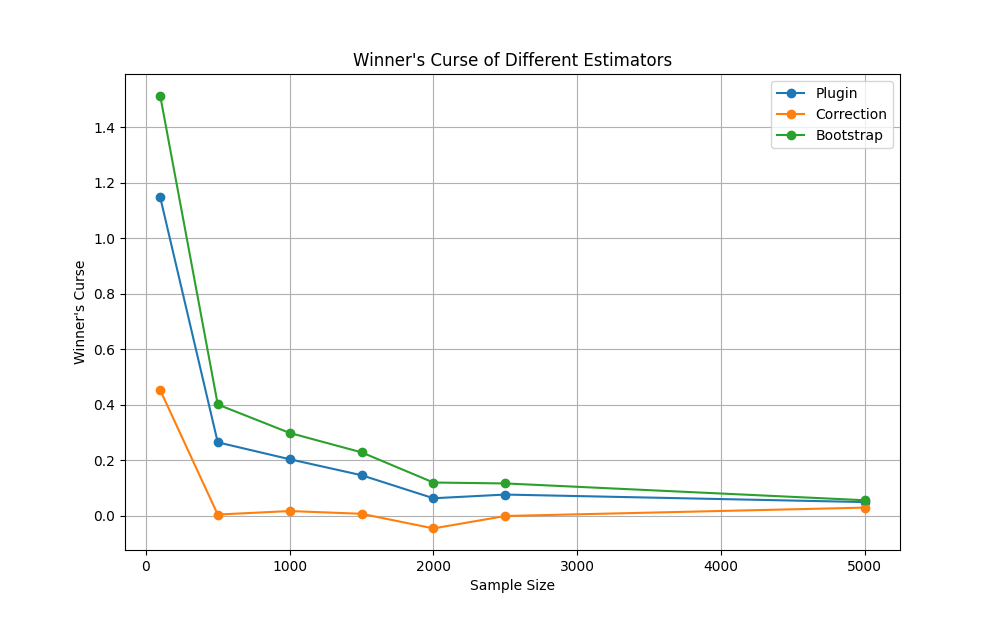

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))
test = result_df[result_df['num_bootstrap'] == 10000]

ax.plot(test['sample_size'], test['plugin_wc'], 'o-', label='Plugin', color='C0')
ax.plot(test['sample_size'], test['corr_wc'], 'o-', label='Correction', color='C1')
ax.plot(test['sample_size'], test['adj_corr_wc'], 'o-', label='Adjusted Correction', color='C2')

ax.set_xlabel('Sample Size')
ax.set_ylabel('Winner\'s Curse')
ax.set_title('Winner\'s Curse of Different Estimators')
ax.grid()
ax.legend()

plt.show()